# Credit Risk — Data Preparation
Cleans, renames columns, imputes missing values, scales features, and saves the output.

In [16]:
import sys, os
# Add project root to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.preprocessing import RobustScaler
from src.LoadData import cs_train

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load & Rename Columns

In [17]:
df = cs_train.copy()

# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns to short, readable names
rename_map = {
    'SeriousDlqin2yrs':                        'default',
    'RevolvingUtilizationOfUnsecuredLines':     'util_rate',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'late_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'income',
    'NumberOfOpenCreditLinesAndLoans':          'open_loans',
    'NumberOfTimes90DaysLate':                  'late_90_plus',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'late_60_89',
    'NumberOfDependents':                       'dependents'
}
df.rename(columns=rename_map, inplace=True)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 150,000 rows x 11 columns


,default,util_rate,age,late_30_59,debt_ratio,income,open_loans,late_90_plus,real_estate_loans,late_60_89,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Missing Values

In [18]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Percentage (%)
income,29731,19.82
dependents,3924,2.62


## 3. Duplicates & Invalid Ages

In [19]:
print(f'Duplicated rows : {df.duplicated().sum():,}')

n_invalid = (df['age'] == 0).sum()
print(f'Invalid ages (0): {n_invalid}')

# Replace 0-age with NaN
df.loc[df['age'] == 0, 'age'] = np.nan
print(f'NaN in age after fix: {df["age"].isnull().sum()}')

Duplicated rows : 609
Invalid ages (0): 1
NaN in age after fix: 1


## 4. Distributions — Columns with Missing Values

In [20]:
missing_cols = ['income', 'dependents', 'age']

print('Skewness:')
print(df[missing_cols].skew().sort_values().round(3))
print('\nDescriptive Statistics:')
df[missing_cols].describe().T.round(2)

Skewness:
age             0.189
dependents      1.588
income        114.040
dtype: float64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
income,120269.0,6670.22,14384.67,0.0,3400.0,5400.0,8249.0,3008750.0
dependents,146076.0,0.76,1.12,0.0,0.0,0.0,1.0,20.0
age,149999.0,52.30,14.77,21.0,41.0,52.0,63.0,109.0


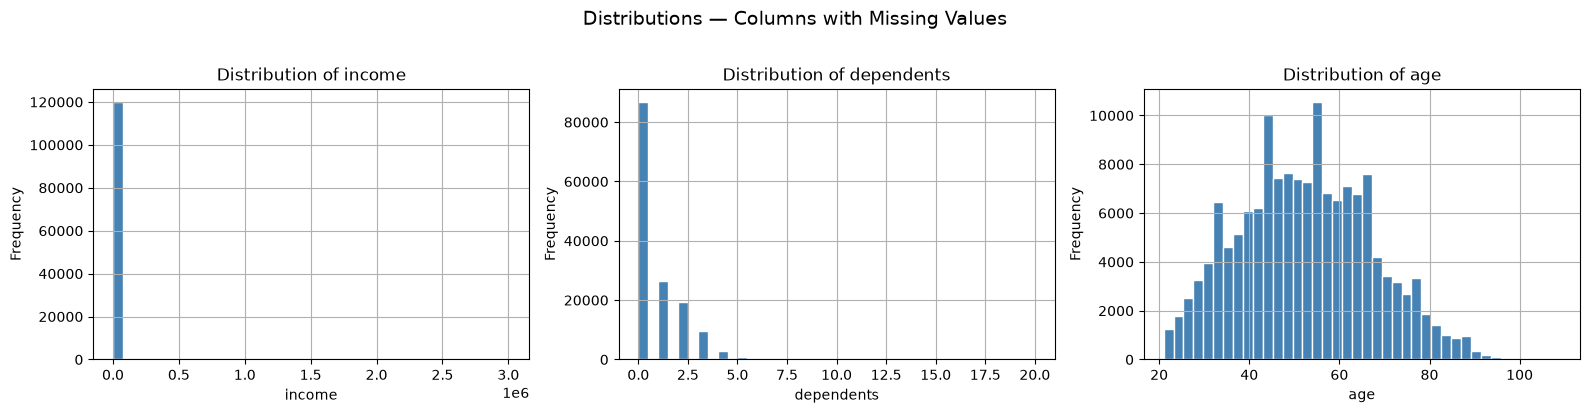

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, missing_cols):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Distributions — Columns with Missing Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

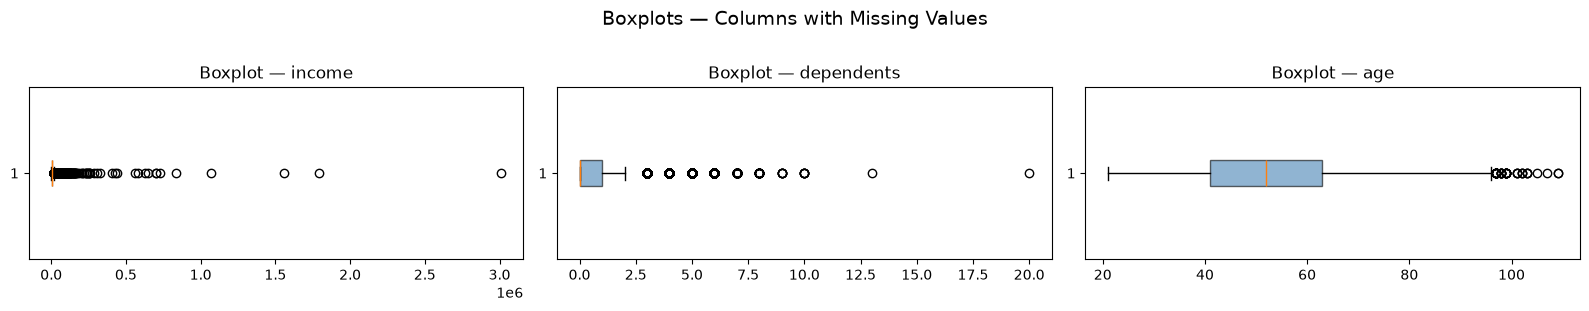

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for ax, col in zip(axes, missing_cols):
    ax.boxplot(df[col].dropna(), orientation='horizontal',
               patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'Boxplot — {col}', fontsize=12)
plt.suptitle('Boxplots — Columns with Missing Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Impute Missing Values (Median)

In [23]:
for col in missing_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'  {col:<15} filled with median = {med:.2f}')

print(f'\nTotal remaining missing values: {df.isnull().sum().sum()}')

  income          filled with median = 5400.00
  dependents      filled with median = 0.00
  age             filled with median = 52.00

Total remaining missing values: 0


## 6. Full Dataset — Distributions & Skewness

In [24]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
skewness = df[numeric_cols].skew().sort_values(ascending=False).round(3)
print('Skewness (sorted):\n')
print(skewness.to_string())

Skewness (sorted):

income               127.122
util_rate             97.632
debt_ratio            95.158
late_60_89            23.332
late_90_plus          23.087
late_30_59            22.597
real_estate_loans      3.482
default                3.469
dependents             1.626
open_loans             1.215
age                    0.189


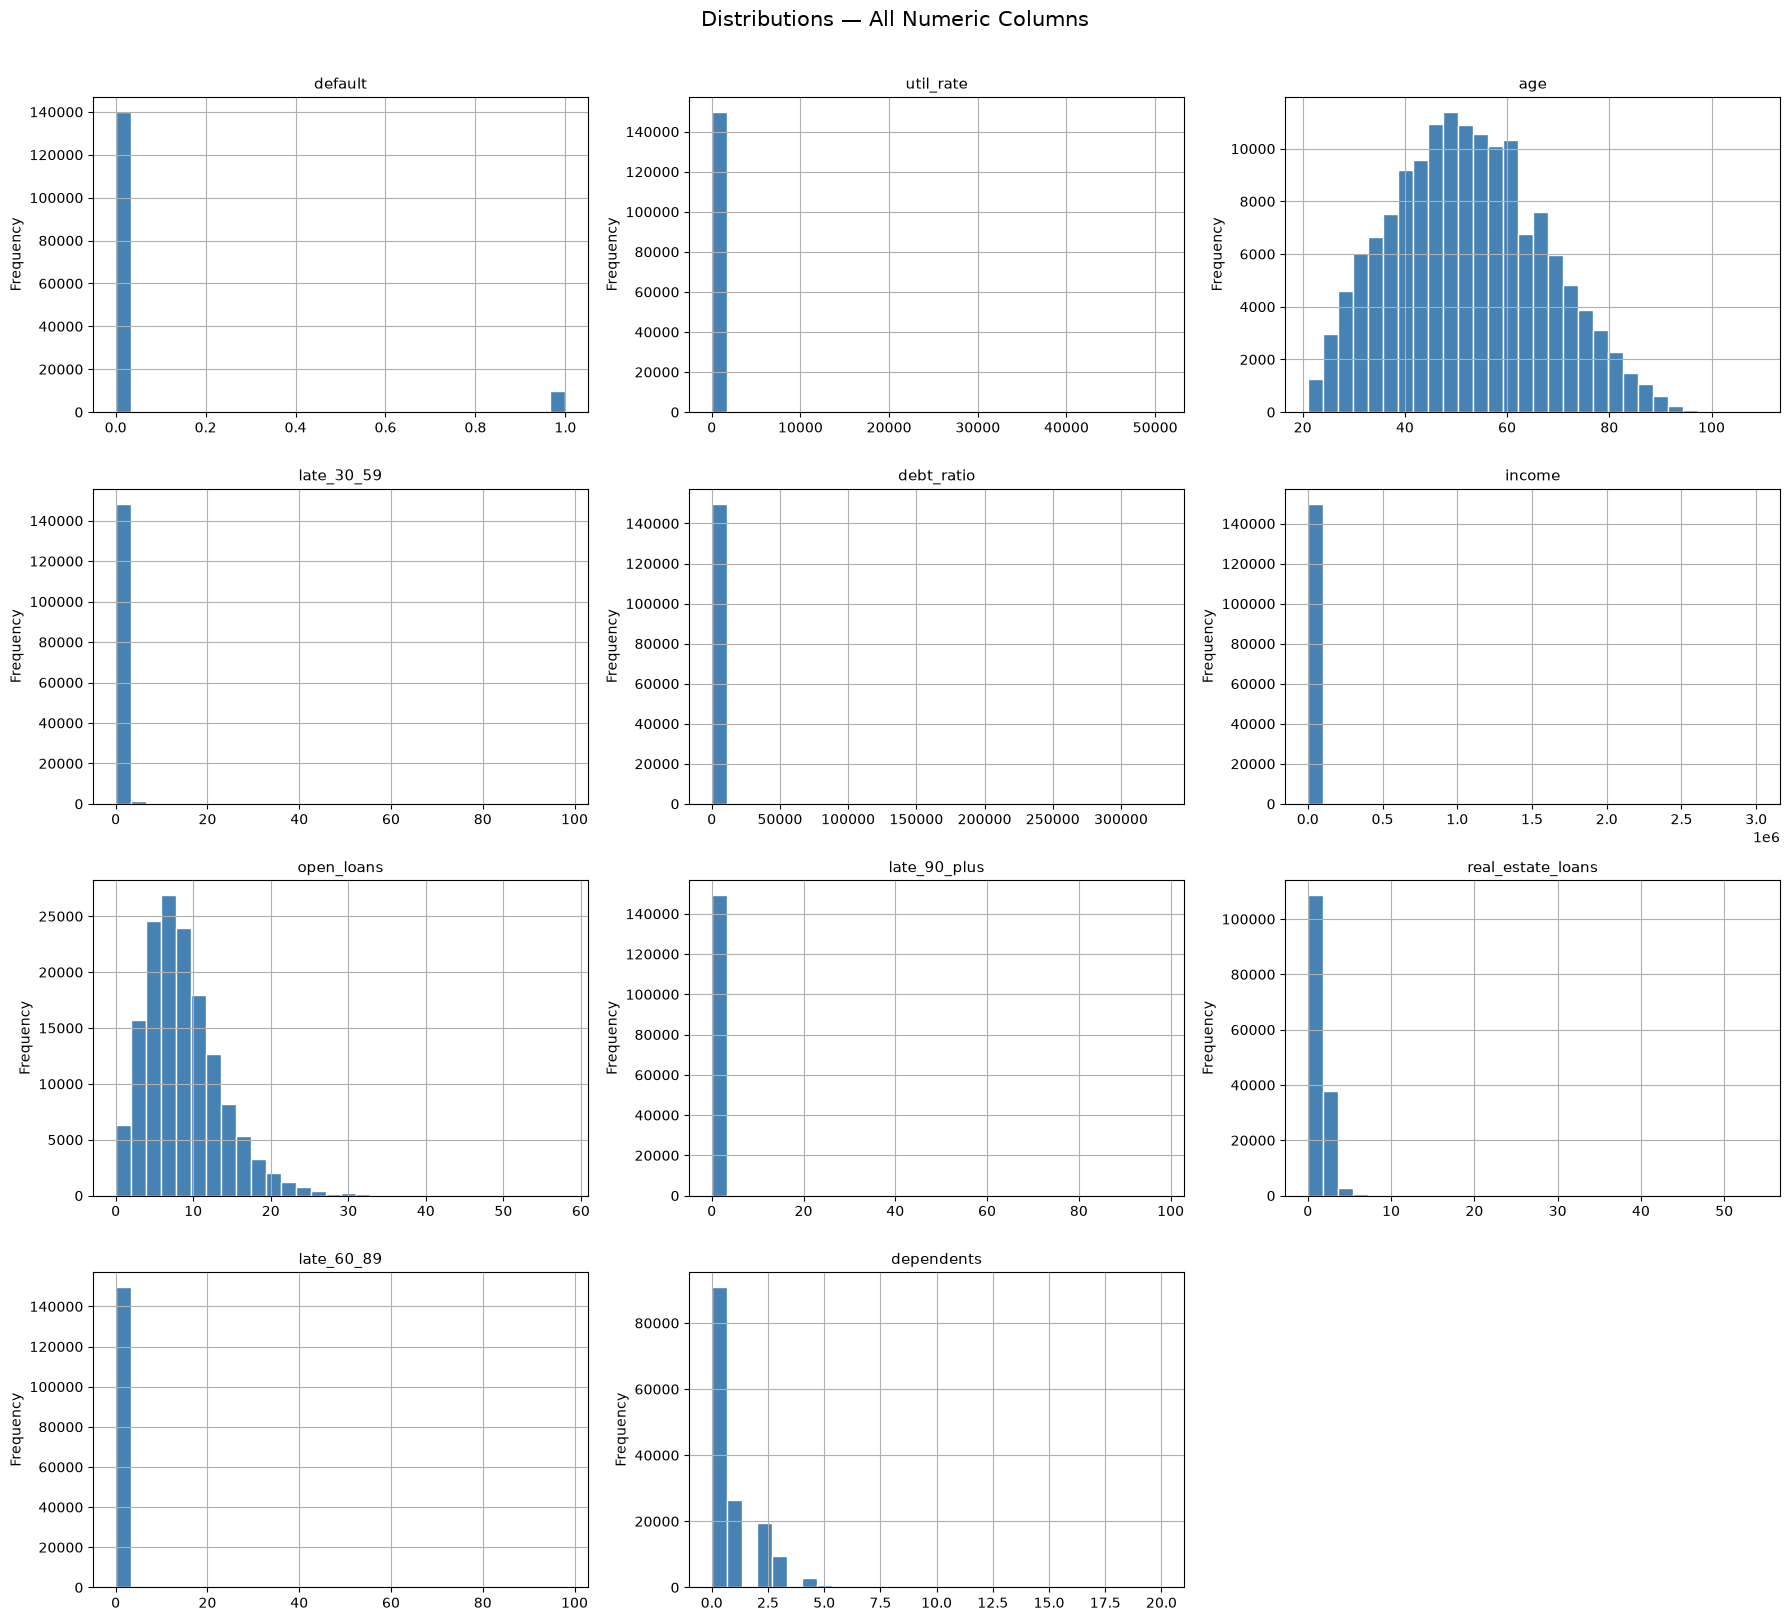

In [25]:
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions — All Numeric Columns', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

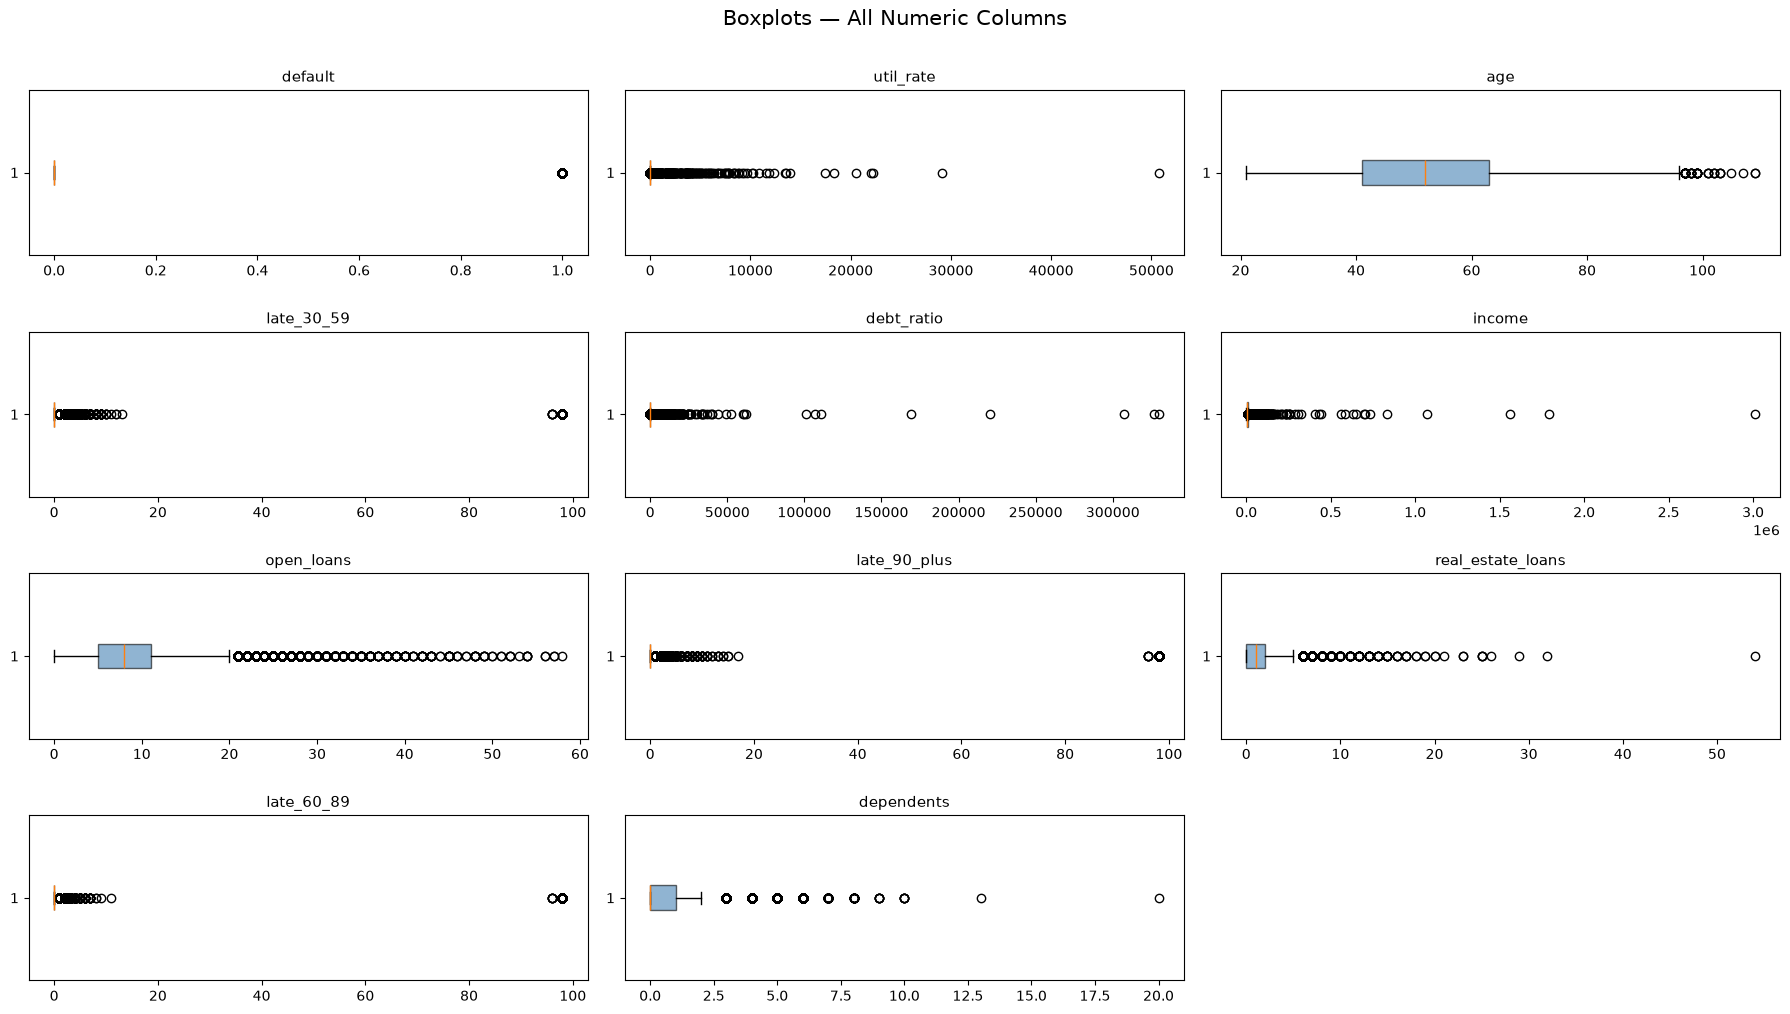

In [26]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], orientation='horizontal',
                    patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — All Numeric Columns', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 7. Categorical Columns

In [27]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print('Categorical columns:', cat_cols)
else:
    print('No categorical columns found.')

No categorical columns found.


## 8. Feature Scaling (RobustScaler)

In [28]:
X = df.drop(columns=['default'])
y = df['default']

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

df_clean = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print(f'Scaled {X.shape[1]} features using RobustScaler')
df_clean.head()

Scaled 10 features using RobustScaler


,util_rate,age,late_30_59,debt_ratio,income,open_loans,late_90_plus,real_estate_loans,late_60_89,dependents,default
0,1.156407,-0.318182,2.0,0.629670,1.063769,0.833333,0.0,2.5,0.0,2.0,1
1,1.517389,-0.545455,0.0,-0.352912,-0.800686,-0.666667,0.0,-0.5,0.0,1.0,0
2,0.952418,-0.636364,1.0,-0.405947,-0.674292,-1.000000,1.0,-0.5,0.0,0.0,0
3,0.150477,-1.000000,0.0,-0.476728,-0.600515,-0.500000,0.0,-0.5,0.0,0.0,0
4,1.423070,-0.136364,1.0,-0.492776,16.639405,-0.166667,0.0,0.0,0.0,0.0,0


## 9. Final Summary & Save

In [29]:
print(f'Shape          : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print(f'Missing values : {df_clean.isnull().sum().sum()}')
print('\nData types:')
print(df_clean.dtypes.value_counts().to_string())
print('\nMissing per column:')
print(df_clean.isnull().sum().to_string())

Shape          : 150,000 rows x 11 columns
Missing values : 0

Data types:
float64    10
int64       1

Missing per column:
util_rate            0
age                  0
late_30_59           0
debt_ratio           0
income               0
open_loans           0
late_90_plus         0
real_estate_loans    0
late_60_89           0
dependents           0
default              0


In [30]:
out_path = os.path.abspath(os.path.join('..', 'data', 'clean_cs_training.csv'))
df_clean.to_csv(out_path, index=False)
print(f'Saved to: {out_path}')

Saved to: c:\Users\ARWA\credit_risk_predictor\data\clean_cs_training.csv
